In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
warnings.filterwarnings('ignore')
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/results', exist_ok=True)
print('Libraries loaded!')

Libraries loaded!


## Step 1 - Load Preprocessed Data
We load the train and test data saved from Notebook 02.

In [14]:
X_train = joblib.load('../data/processed/X_train.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')
print('Data loaded!')
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

Data loaded!
X_train shape: (10643, 12)
X_test shape : (2661, 12)


## Step 2 - Evaluation Function
One function to evaluate all models the same way.

In [15]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    accuracy    = accuracy_score(y_test, y_pred)
    precision   = precision_score(y_test, y_pred)
    recall      = recall_score(y_test, y_pred)
    f1          = f1_score(y_test, y_pred)
    auc         = roc_auc_score(y_test, y_pred_prob)
    print(f'\n=== {model_name} ===')
    print(f'Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
    print(f'Precision : {precision:.4f}')
    print(f'Recall    : {recall:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print(f'AUC Score : {auc:.4f}')
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1 Score' : round(f1, 4),
        'AUC'      : round(auc, 4)
    }
print('Evaluation function ready!')

Evaluation function ready!


## Step 3 - Model 1: Random Forest (Baseline)
Random Forest is our baseline. All other models must beat this.
It builds many decision trees and combines their predictions.

In [16]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators = 150,
    max_depth    = 9,
    min_samples_leaf = 4,
    random_state = 42
)
rf_model.fit(X_train, y_train)
print('Random Forest training done!')

Training Random Forest...
Random Forest training done!



=== Random Forest ===
Accuracy  : 0.9004  (90.04%)
Precision : 0.9047
Recall    : 0.8944
F1 Score  : 0.8995
AUC Score : 0.9237


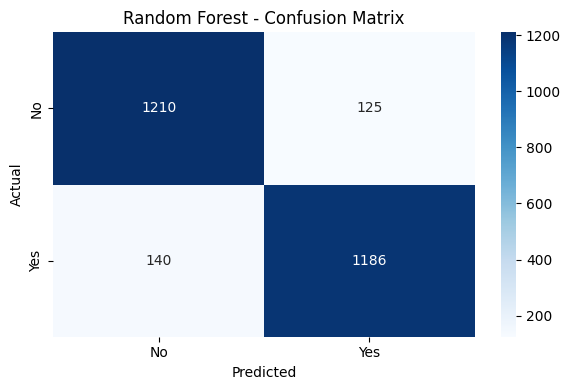

In [17]:
rf_results = evaluate_model(rf_model, X_test, y_test, 'Random Forest')
cm = confusion_matrix(y_test, rf_model.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_rf.png')
plt.show()

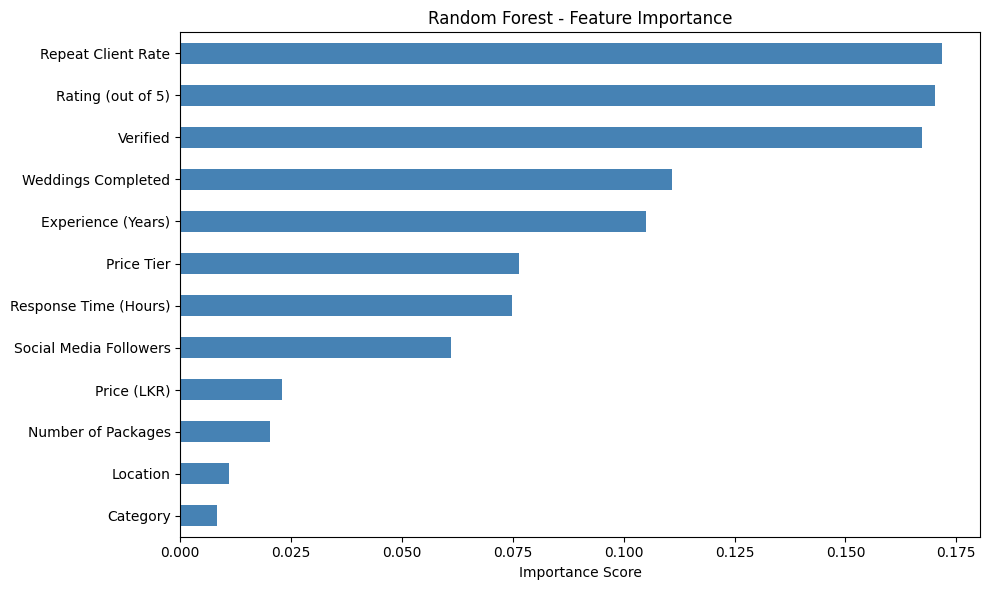

Random Forest model saved!


In [18]:
fi = pd.Series(rf_model.feature_importances_,
               index=X_train.columns).sort_values(ascending=True)
fi.plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_rf.png')
plt.show()
joblib.dump(rf_model, '../models/random_forest.pkl')
print('Random Forest model saved!')

## Step 4 - Model 2: XGBoost (Comparison)
XGBoost improves on Random Forest by building trees sequentially.
Each new tree fixes the mistakes of the previous trees.

In [19]:
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators    = 200,
    max_depth       = 5,
    learning_rate   = 0.08,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    random_state    = 42,
    eval_metric     = 'logloss',
    verbosity       = 0
)
xgb_model.fit(X_train, y_train)
print('XGBoost training done!')

Training XGBoost...
XGBoost training done!



=== XGBoost ===
Accuracy  : 0.9000  (90.00%)
Precision : 0.9003
Recall    : 0.8989
F1 Score  : 0.8996
AUC Score : 0.9216


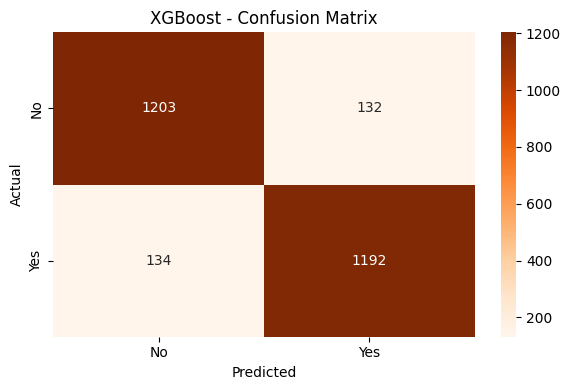

XGBoost model saved!


In [20]:
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
cm = confusion_matrix(y_test, xgb_model.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_xgb.png')
plt.show()
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print('XGBoost model saved!')

## Step 5 - Model 3: CatBoost (Best Single Model)
CatBoost is the best individual model for Weddify because:
- Our dataset has 4 categorical columns: Category, Location, Price Tier, Verified
- CatBoost handles categorical features natively without manual encoding
- CatBoost uses ordered boosting to prevent overfitting
- CatBoost builds symmetric trees which generalise better
- Research shows CatBoost outperforms XGBoost and RF on categorical-heavy datasets

In [21]:
print('Training CatBoost...')
cat_model = CatBoostClassifier(
    iterations    = 300,
    depth         = 6,
    learning_rate = 0.08,
    l2_leaf_reg   = 4,
    random_seed   = 42,
    verbose       = 0
)
cat_model.fit(X_train, y_train)
print('CatBoost training done!')

Training CatBoost...
CatBoost training done!



=== CatBoost ===
Accuracy  : 0.9049  (90.49%)
Precision : 0.9049
Recall    : 0.9042
F1 Score  : 0.9046
AUC Score : 0.9211


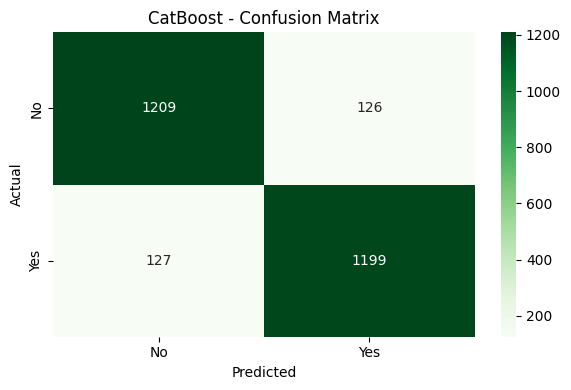

In [22]:
cat_results = evaluate_model(cat_model, X_test, y_test, 'CatBoost')
cm = confusion_matrix(y_test, cat_model.predict(X_test))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title('CatBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_cat.png')
plt.show()

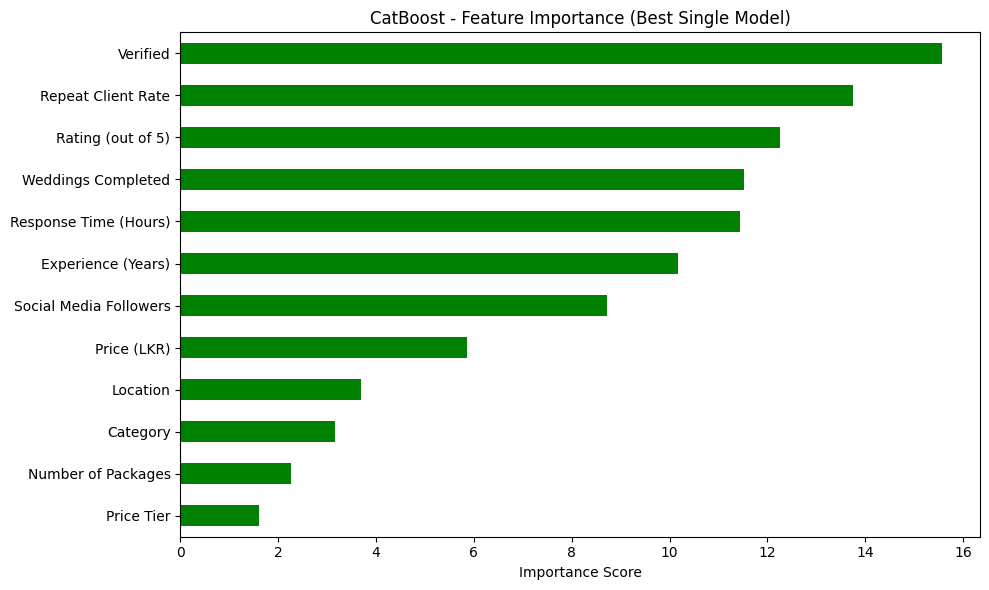

CatBoost model saved!


In [23]:
fi = pd.Series(cat_model.get_feature_importance(),
               index=X_train.columns).sort_values(ascending=True)
fi.plot(kind='barh', color='green', figsize=(10, 6))
plt.title('CatBoost - Feature Importance (Best Single Model)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_catboost.png')
plt.show()
joblib.dump(cat_model, '../models/catboost_model.pkl')
print('CatBoost model saved!')

In [24]:
# Full classification report for CatBoost
print('=== CatBoost - Full Classification Report ===')
print(classification_report(
    y_test,
    cat_model.predict(X_test),
    target_names=['Not Recommended', 'Recommended']
))

=== CatBoost - Full Classification Report ===
                 precision    recall  f1-score   support

Not Recommended       0.90      0.91      0.91      1335
    Recommended       0.90      0.90      0.90      1326

       accuracy                           0.90      2661
      macro avg       0.90      0.90      0.90      2661
   weighted avg       0.90      0.90      0.90      2661



## Step 6 - Compare All 3 Models

In [25]:
results_df = pd.DataFrame([rf_results, xgb_results, cat_results]).set_index('Model')
print('=== Model Comparison ===')
print(results_df.to_string())
print(f'\nBest single model: CatBoost')
print(f'  Accuracy : {cat_results["Accuracy"]*100:.2f}%')
print(f'  AUC      : {cat_results["AUC"]}')
print(f'  F1 Score : {cat_results["F1 Score"]}')

=== Model Comparison ===
               Accuracy  Precision  Recall  F1 Score     AUC
Model                                                       
Random Forest    0.9004     0.9047  0.8944    0.8995  0.9237
XGBoost          0.9000     0.9003  0.8989    0.8996  0.9216
CatBoost         0.9049     0.9049  0.9042    0.9046  0.9211

Best single model: CatBoost
  Accuracy : 90.49%
  AUC      : 0.9211
  F1 Score : 0.9046


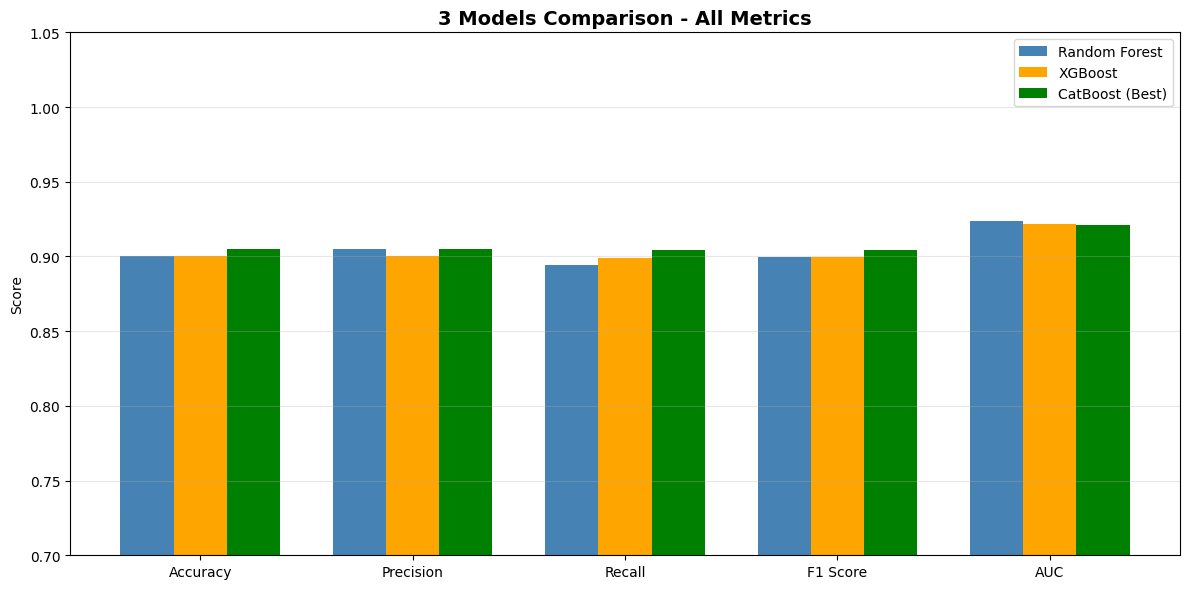

In [26]:
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
x        = np.arange(len(metrics))
width    = 0.25
fig, ax  = plt.subplots(figsize=(12, 6))
ax.bar(x - width, results_df.loc['Random Forest'][metrics], width,
       label='Random Forest', color='steelblue')
ax.bar(x,         results_df.loc['XGBoost'][metrics],       width,
       label='XGBoost',       color='orange')
ax.bar(x + width, results_df.loc['CatBoost'][metrics],      width,
       label='CatBoost (Best)', color='green')
ax.set_title('3 Models Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png')
plt.show()

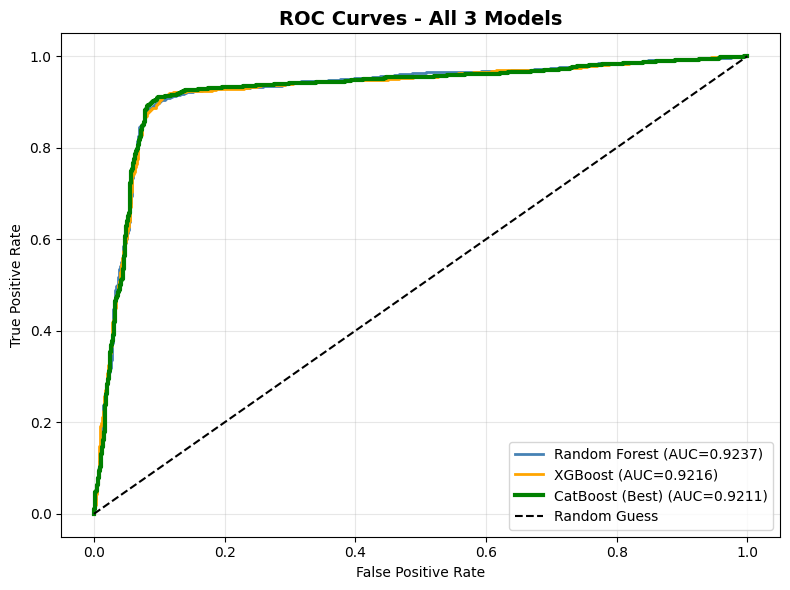

In [27]:
plt.figure(figsize=(8, 6))
for model, name, color, lw in [
    (rf_model,  'Random Forest', 'steelblue', 2),
    (xgb_model, 'XGBoost',       'orange',    2),
    (cat_model, 'CatBoost (Best)', 'green',   3)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})',
             color=color, linewidth=lw)
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.title('ROC Curves - All 3 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves_3_models.png')
plt.show()

In [28]:
results_df.to_csv('../outputs/results/model_comparison_table.csv')
print('Comparison table saved!')
print('\nAll 3 models saved to models/ folder.')
print('CatBoost is the best single model - it will be used as the base for hybrid model.')

Comparison table saved!

All 3 models saved to models/ folder.
CatBoost is the best single model - it will be used as the base for hybrid model.
